<a href="https://colab.research.google.com/github/shriya7756/BDAassignment/blob/main/BDA_Assignment2_087.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2: Clustering Model with Spark
### Dataset: Mall Customer Segmentation (Extended)
> We segment mall customers into distinct groups based on their age, annual income, spending score, and visit frequency — enabling targeted marketing strategies.

**Model Used:** K-Means Clustering + Optimal K via Elbow Method

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(7)
n = 800

# Simulate 5 distinct customer clusters
segments = {
    'Young High-Spenders':    {'age': (22,30), 'income': (30,55),  'score': (70,100), 'visits': (8,15)},
    'Middle Balanced':        {'age': (30,45), 'income': (50,75),  'score': (40,65),  'visits': (4,8)},
    'Senior Savers':          {'age': (50,70), 'income': (25,45),  'score': (10,35),  'visits': (1,4)},
    'High-Income Low-Spend':  {'age': (35,55), 'income': (75,140), 'score': (5,30),   'visits': (2,6)},
    'High-Income High-Spend': {'age': (28,40), 'income': (80,140), 'score': (65,100), 'visits': (10,20)},
}

records = []
per_seg = n // len(segments)
for seg_name, params in segments.items():
    for _ in range(per_seg):
        records.append({
            'CustomerID':    len(records) + 1,
            'Gender':        np.random.choice(['Male', 'Female']),
            'Age':           np.random.randint(*params['age']),
            'AnnualIncome':  np.random.randint(*params['income']),
            'SpendingScore': np.random.randint(*params['score']),
            'VisitsPerMonth':np.random.randint(*params['visits']),
            'TrueSegment':   seg_name
        })

mall_df = pd.DataFrame(records).sample(frac=1, random_state=7).reset_index(drop=True)
print(f"Dataset shape: {mall_df.shape}")
mall_df.head()

Dataset shape: (800, 7)


,CustomerID,Gender,Age,AnnualIncome,SpendingScore,VisitsPerMonth,TrueSegment
0,62,Male,22,44,85,14,Young High-Spenders
1,800,Male,35,101,82,13,High-Income High-Spend
2,748,Male,36,138,68,14,High-Income High-Spend
3,669,Male,34,112,68,10,High-Income High-Spend
4,727,Male,38,104,83,15,High-Income High-Spend


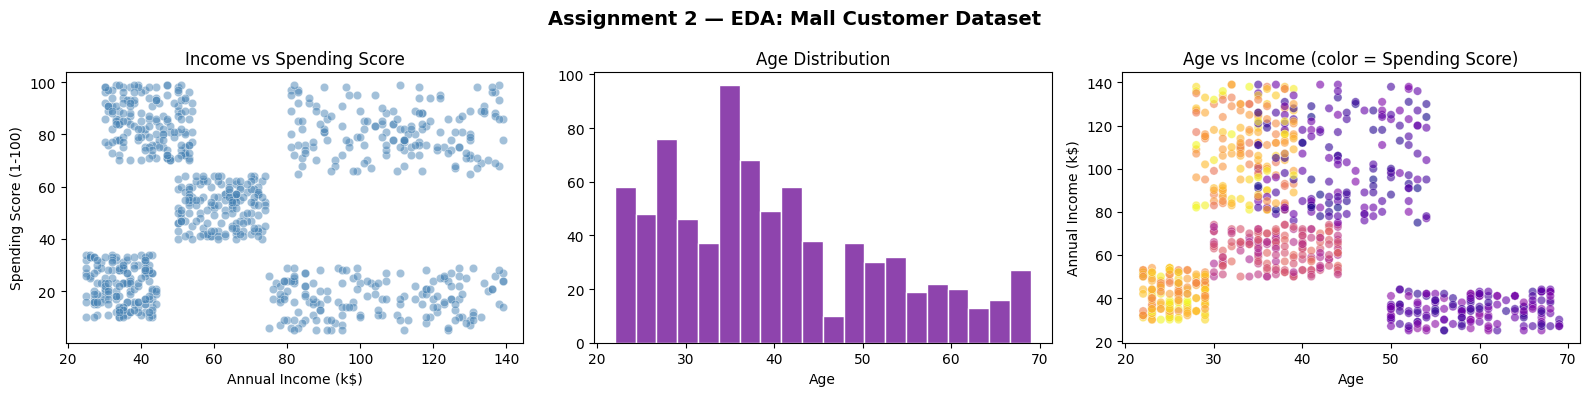

In [ ]:
# ── EDA ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Assignment 2 — EDA: Mall Customer Dataset', fontsize=14, fontweight='bold')

axes[0].scatter(mall_df['AnnualIncome'], mall_df['SpendingScore'],
                alpha=0.5, c='steelblue', edgecolors='white', linewidths=0.4)
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score (1-100)')
axes[0].set_title('Income vs Spending Score')

axes[1].hist(mall_df['Age'], bins=20, color='#8E44AD', edgecolor='white')
axes[1].set_title('Age Distribution')
axes[1].set_xlabel('Age')

axes[2].scatter(mall_df['Age'], mall_df['AnnualIncome'],
                c=mall_df['SpendingScore'], cmap='plasma', alpha=0.6, edgecolors='white', linewidths=0.3)
axes[2].set_xlabel('Age')
axes[2].set_ylabel('Annual Income (k$)')
axes[2].set_title('Age vs Income (color = Spending Score)')

plt.tight_layout()
plt.show()

In [ ]:
from pyspark.sql import SparkSession
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.sql.types import StructType, StructField, IntegerType, StringType # Import necessary types

# Initialize SparkSession
sprk = SparkSession.builder.appName("KMeansClustering").getOrCreate()

# Define the schema explicitly for the DataFrame
# This helps PySpark correctly interpret column types, especially for strings
# that might be represented as numpy.str_ from pandas.
schema = StructType([
    StructField("CustomerID", IntegerType(), True),
    StructField("Gender", StringType(), True), # Explicitly set Gender as StringType
    StructField("Age", IntegerType(), True),
    StructField("AnnualIncome", IntegerType(), True),
    StructField("SpendingScore", IntegerType(), True),
    StructField("VisitsPerMonth", IntegerType(), True),
])

# Convert numerical columns to standard Python int types to avoid numpy.dtype serialization issues
# Using .apply(int) ensures conversion to native Python int, which is more robust than .astype(int)
for col in ['CustomerID', 'Age', 'AnnualIncome', 'SpendingScore', 'VisitsPerMonth']:
    mall_df[col] = mall_df[col].apply(int)

# Convert string columns to standard Python str types to avoid numpy.dtype serialization issues
mall_df['Gender'] = mall_df['Gender'].apply(str)

# Convert the Pandas DataFrame to a list of Python dictionaries (records)
# This explicitly creates a structure with native Python types, bypassing numpy.dtype issues.
pandas_df_for_spark = mall_df.drop(columns=['TrueSegment']).to_dict('records')

# ── Load into Spark ──
# Create Spark DataFrame with the explicit schema from the list of records
sdf_mall = sprk.createDataFrame(pandas_df_for_spark, schema=schema)

feature_cols_cluster = ['Age', 'AnnualIncome', 'SpendingScore', 'VisitsPerMonth']

assembler_c = VectorAssembler(inputCols=feature_cols_cluster, outputCol='raw_features')
scaler_c    = StandardScaler(inputCol='raw_features', outputCol='features',
                              withStd=True, withMean=True)

# ── Elbow Method to find optimal K ──
print("Running Elbow Method (K = 2 to 10)...")
wcss_values = []
silhouette_values = []
k_range = range(2, 11)

prep_pipeline = Pipeline(stages=[assembler_c, scaler_c])
prepared_data = prep_pipeline.fit(sdf_mall).transform(sdf_mall)

for k in k_range:
    km = KMeans(featuresCol='features', predictionCol='cluster', k=k, seed=42, maxIter=50)
    km_model = km.fit(prepared_data)
    wcss_values.append(km_model.summary.trainingCost)

    evaluator_sil = ClusteringEvaluator(featuresCol='features',
                                         predictionCol='cluster',
                                         metricName='silhouette')
    preds = km_model.transform(prepared_data)
    sil = evaluator_sil.evaluate(preds)
    silhouette_values.append(sil)
    print(f"  K={k} | WCSS={km_model.summary.trainingCost:.2f} | Silhouette={sil:.4f}")

print("\n Elbow analysis done!")

Running Elbow Method (K = 2 to 10)...
  K=2 | WCSS=1551.94 | Silhouette=0.6338
  K=3 | WCSS=1052.89 | Silhouette=0.6268
  K=4 | WCSS=659.29 | Silhouette=0.6708
  K=5 | WCSS=382.83 | Silhouette=0.7699
  K=6 | WCSS=339.77 | Silhouette=0.7260
  K=7 | WCSS=321.27 | Silhouette=0.6505
  K=8 | WCSS=295.01 | Silhouette=0.6004
  K=9 | WCSS=284.44 | Silhouette=0.5970
  K=10 | WCSS=237.97 | Silhouette=0.5453

 Elbow analysis done!


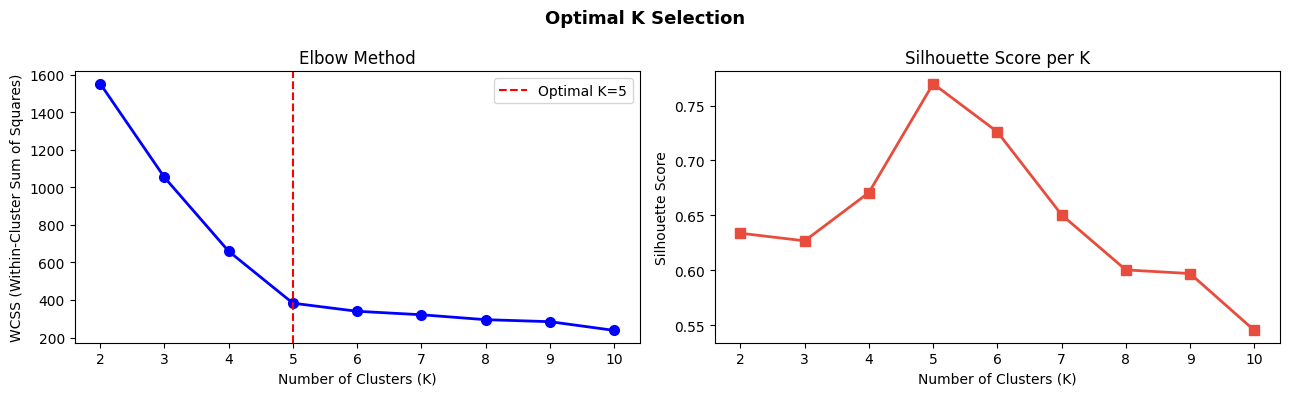

In [ ]:
# ── Plot Elbow + Silhouette ──
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Optimal K Selection', fontsize=13, fontweight='bold')

ax1.plot(list(k_range), wcss_values, 'bo-', linewidth=2, markersize=7)
ax1.axvline(x=5, color='red', linestyle='--', label='Optimal K=5')
ax1.set_xlabel('Number of Clusters (K)')
ax1.set_ylabel('WCSS (Within-Cluster Sum of Squares)')
ax1.set_title('Elbow Method')
ax1.legend()

ax2.plot(list(k_range), silhouette_values, 's-', color='#E74C3C', linewidth=2, markersize=7)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score per K')

plt.tight_layout()
plt.show()

In [ ]:
# ── Final KMeans with K=5 ──
optimal_k = 5
km_final = KMeans(featuresCol='features', predictionCol='Cluster',
                   k=optimal_k, seed=42, maxIter=100, tol=1e-4)

final_pipeline = Pipeline(stages=[assembler_c, scaler_c, km_final])
final_model    = final_pipeline.fit(sdf_mall)
clustered      = final_model.transform(sdf_mall)

# Silhouette on final model
evaluator_final = ClusteringEvaluator(featuresCol='features',
                                       predictionCol='Cluster',
                                       metricName='silhouette')
final_sil = evaluator_final.evaluate(clustered)

print("="*45)
print(f" K-Means Clustering Results (K={optimal_k})")
print("="*45)
print(f"  Silhouette Score : {final_sil:.4f}")
print("="*45)

 K-Means Clustering Results (K=5)
  Silhouette Score : 0.7699



Cluster Profiles:
         AvgAge  AvgIncome  AvgSpending  AvgVisits  Count
Cluster                                                  
0          33.7      109.6         81.3       14.6    159
1          59.3       34.7         22.0        2.1    160
2          25.5       42.0         84.5       11.3    160
3          37.6       62.3         52.4        5.6    161
4          44.4      104.4         17.3        3.5    160


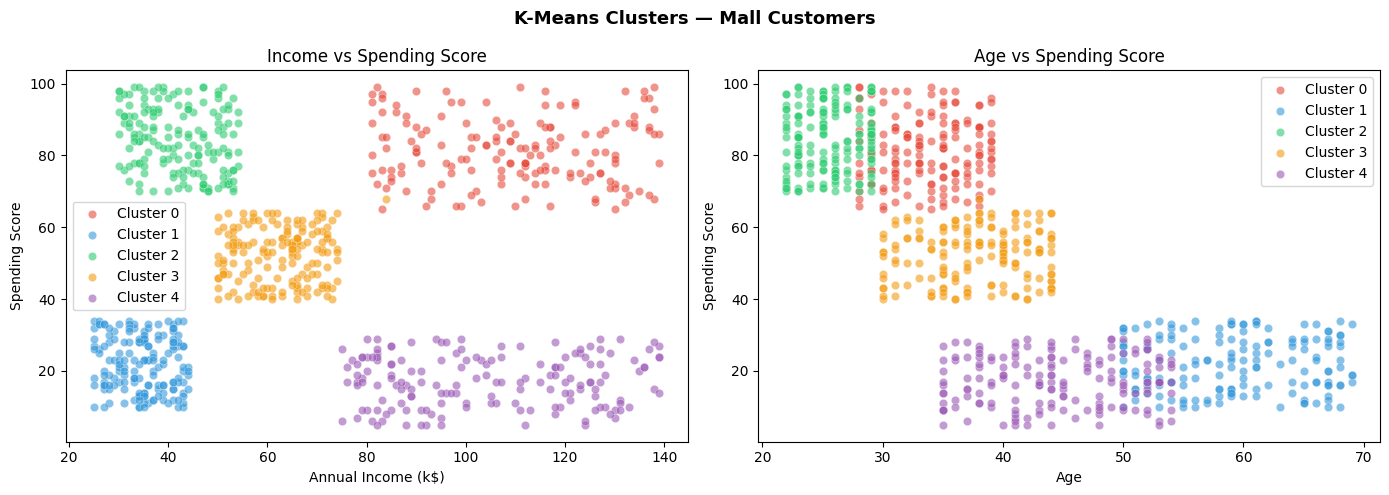

In [ ]:
# ── Cluster Profiling ──
cluster_pdf = clustered.select(
    'Age', 'AnnualIncome', 'SpendingScore', 'VisitsPerMonth', 'Cluster'
).toPandas()

profile = cluster_pdf.groupby('Cluster').agg(
    AvgAge=('Age','mean'),
    AvgIncome=('AnnualIncome','mean'),
    AvgSpending=('SpendingScore','mean'),
    AvgVisits=('VisitsPerMonth','mean'),
    Count=('Cluster','count')
).round(1)

print("\nCluster Profiles:")
print(profile.to_string())

# ── 2D Scatter Plot by Cluster ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('K-Means Clusters — Mall Customers', fontsize=13, fontweight='bold')

colors = ['#E74C3C','#3498DB','#2ECC71','#F39C12','#9B59B6']
for c in range(optimal_k):
    subset = cluster_pdf[cluster_pdf['Cluster'] == c]
    axes[0].scatter(subset['AnnualIncome'], subset['SpendingScore'],
                    label=f'Cluster {c}', color=colors[c], alpha=0.6, edgecolors='white', linewidths=0.3)
    axes[1].scatter(subset['Age'], subset['SpendingScore'],
                    label=f'Cluster {c}', color=colors[c], alpha=0.6, edgecolors='white', linewidths=0.3)

axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Spending Score')
axes[0].set_title('Income vs Spending Score')
axes[0].legend()

axes[1].set_xlabel('Age')
axes[1].set_ylabel('Spending Score')
axes[1].set_title('Age vs Spending Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ── Cluster Centers (de-normalized) ──
scaler_model = final_model.stages[1]
means  = scaler_model.mean.toArray()
stds   = scaler_model.std.toArray()

centers_scaled = final_model.stages[2].clusterCenters()
centers_real   = [(c * stds + means) for c in centers_scaled]

print("\n📍 Cluster Centroids (Original Scale):")
print(f"{'Cluster':<10}{'Age':<8}{'Income':<12}{'SpendScore':<14}{'Visits':<8}")
print("-" * 52)
for i, center in enumerate(centers_real):
    print(f"{i:<10}{center[0]:<8.1f}{center[1]:<12.1f}{center[2]:<14.1f}{center[3]:<8.1f}")


📍 Cluster Centroids (Original Scale):
Cluster   Age     Income      SpendScore    Visits  
----------------------------------------------------
0         33.7    109.6       81.3          14.6    
1         59.3    34.7        22.0          2.1     
2         25.5    42.0        84.5          11.3    
3         37.6    62.3        52.4          5.6     
4         44.4    104.4       17.3          3.5     


**Explanation2:**

> Add blockquote


- K-Means with K=5 identifies five distinct customer segments in the mall data.  
- The elbow method and silhouette score both confirm K=5 as the optimal number of clusters.  
- Cluster profiles reveal actionable insights: high-income low-spenders can be targeted with loyalty perks, while young high-spenders are already valuable and need retention strategies.  
- PySpark's MLlib efficiently scales K-Means to large datasets that wouldn't fit in memory for traditional scikit-learn.